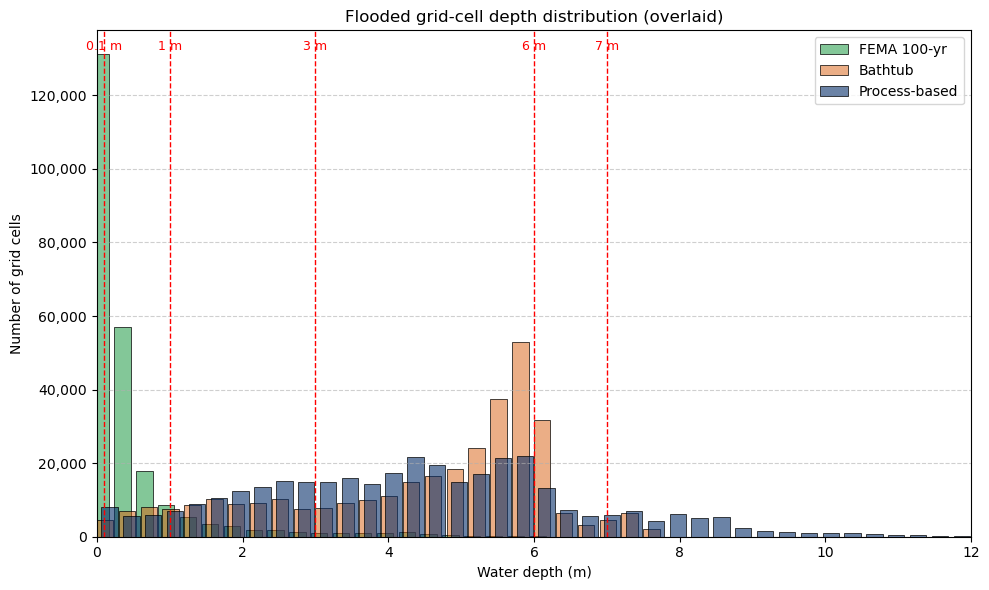

In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# ---------------- USER INPUT ----------------
# Rasters
r_fema     = r"D:\Phd Research\Final_Raster\Fema_100yr_depth_200m.tif"
r_bathtub  = r"D:\Phd Research\Final_Raster\Bathtub_depth_100yr_surge_SLR.tif"
r_compound = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"

# Binning and refs
bin_width = 0.3            # meters
x_max = 12.0               # maximum depth to show on x-axis
ref_lines = [0.1, 1.0, 3.0, 6.0, 7.0]

# Plot appearance
colors = {
    "FEMA 100-yr": (49/255, 163/255, 84/255, 0.60),    # green
    "Bathtub":     (217/255, 95/255,  14/255, 0.50),   # orange
    "Process-based": (8/255, 48/255, 107/255, 0.60),   # dark blue
}

# Optional: area-normalize bars (km² per bin) instead of cell counts
AREA_NORMALIZE = False
# --------------------------------------------

def depth_values(path, clip_max=None):
    """Read depth raster and return 1D array of valid depths > 0 (optionally ≤ clip_max),
       plus pixel area (m²) if projected in meters, else None."""
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            valid = (arr != nodata) & np.isfinite(arr)
        else:
            valid = np.isfinite(arr)
        vals = arr[valid]
        vals = vals[vals > 0]  # flooded only
        if clip_max is not None:
            vals = vals[vals <= clip_max]

        # pixel area if projected
        pix_area = None
        try:
            if src.crs and not src.crs.is_geographic:
                pix_area = abs(src.transform.a) * abs(src.transform.e)  # m²/pixel
        except Exception:
            pass
    return vals, pix_area

# Common bins across datasets
bins = np.arange(0, x_max + bin_width, bin_width)

series = [
    ("FEMA 100-yr", r_fema),
    ("Bathtub", r_bathtub),
    ("Process-based", r_compound),
]

# Compute histograms
hists = []
for name, path in series:
    vals, pix_area = depth_values(path, clip_max=x_max)
    counts, edges = np.histogram(vals, bins=bins)
    if AREA_NORMALIZE:
        if pix_area is None:
            print(f"[WARN] {name}: CRS appears geographic; area normalization skipped for this raster.")
            heights = counts.astype(float)  # fallback to counts
        else:
            heights = counts * (pix_area / 1e6)  # km² per bin
    else:
        heights = counts
    hists.append((name, heights))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Small offsets so bars are visible when overlapping
offsets = {
    "FEMA 100-yr": -0.20 * bin_width,
    "Bathtub":      0.00 * bin_width,
    "Process-based": 0.20 * bin_width,
}

for name, heights in hists:
    offset = offsets[name]
    ax.bar(
        bins[:-1] + offset, heights,
        width=bin_width * 0.75,  # slightly narrower than bin to reduce total overlap
        align="edge",
        edgecolor="black",
        linewidth=0.5,
        color=colors[name],
        label=name
    )

# Axis labels, title
ax.set_xlim(0, x_max)
ax.set_xlabel("Water depth (m)")
if AREA_NORMALIZE:
    ax.set_ylabel("Area per depth bin (km²)")
else:
    ax.set_ylabel("Number of grid cells")

ax.set_title("Flooded grid-cell depth distribution (overlaid)")

# Format y axis with thousands separators for readability
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Reference vertical lines
for x in ref_lines:
    if 0 <= x <= x_max:
        ax.axvline(x, linestyle="--", color="red", linewidth=1)
        ax.text(x, ax.get_ylim()[1]*0.98, f"{x:g} m",
                color="red", ha="center", va="top", fontsize=9)

ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend(loc="upper right", frameon=True)
fig.tight_layout()
plt.show()


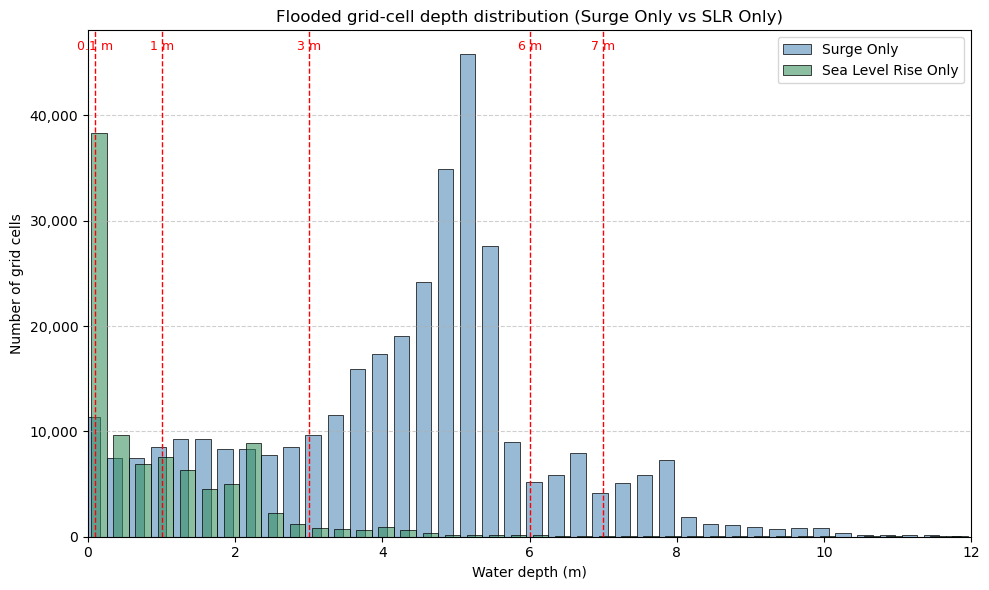

In [3]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# ---------------- USER INPUT ----------------
# Rasters
r_surge = r"D:\Phd Research\inundation depth 100 yr surge only.tif"
r_slr   = r"D:\Phd Research\inundation depth only SLR.tif"

# Binning and refs
bin_width = 0.3            # meters
x_max = 12.0               # maximum depth to show on x-axis
ref_lines = [0.1, 1.0, 3.0, 6.0, 7.0]

# Plot appearance
colors = {
    "Surge Only": (70/255, 130/255, 180/255, 0.55),   # steelblue
    "Sea Level Rise Only": (46/255, 139/255, 87/255, 0.55),  # seagreen
}

# Optional: area-normalize bars (km² per bin) instead of cell counts
AREA_NORMALIZE = False
# --------------------------------------------

def depth_values(path, clip_max=None):
    """Return depths >0 (and <= clip_max if set), plus pixel area (m²) if CRS in meters."""
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata
        valid = np.isfinite(arr) if nodata is None else ((arr != nodata) & np.isfinite(arr))
        vals = arr[valid]
        vals = vals[vals > 0]  # flooded only
        if clip_max is not None:
            vals = vals[vals <= clip_max]

        pix_area = None
        try:
            if src.crs and not src.crs.is_geographic:
                pix_area = abs(src.transform.a) * abs(src.transform.e)  # m²/pixel
        except Exception:
            pass
    return vals, pix_area

# Common bins across datasets
bins = np.arange(0, x_max + bin_width, bin_width)

series = [
    ("Surge Only", r_surge),
    ("Sea Level Rise Only", r_slr),
]

# Compute histograms
hists = []
for name, path in series:
    vals, pix_area = depth_values(path, clip_max=x_max)
    counts, edges = np.histogram(vals, bins=bins)
    if AREA_NORMALIZE:
        if pix_area is None:
            print(f"[WARN] {name}: CRS appears geographic; area normalization skipped.")
            heights = counts.astype(float)
        else:
            heights = counts * (pix_area / 1e6)  # km² per bin
    else:
        heights = counts
    hists.append((name, heights))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Small offsets so bars are visible when overlapping
offsets = {
    "Surge Only": -0.15 * bin_width,
    "Sea Level Rise Only": 0.15 * bin_width,
}

for name, heights in hists:
    offset = offsets[name]
    ax.bar(
        bins[:-1] + offset, heights,
        width=bin_width * 0.7,
        align="edge",
        edgecolor="black",
        linewidth=0.5,
        color=colors[name],
        label=name
    )

# Axis labels, title
ax.set_xlim(0, x_max)
ax.set_xlabel("Water depth (m)")
ax.set_ylabel("Area per depth bin (km²)" if AREA_NORMALIZE else "Number of grid cells")
ax.set_title("Flooded grid-cell depth distribution (Surge Only vs SLR Only)")

# Format y axis
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Reference vertical lines
for x in ref_lines:
    if 0 <= x <= x_max:
        ax.axvline(x, linestyle="--", color="red", linewidth=1)
        ax.text(x, ax.get_ylim()[1]*0.98, f"{x:g} m",
                color="red", ha="center", va="top", fontsize=9)

ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend(loc="upper right", frameon=True)
fig.tight_layout()
plt.show()


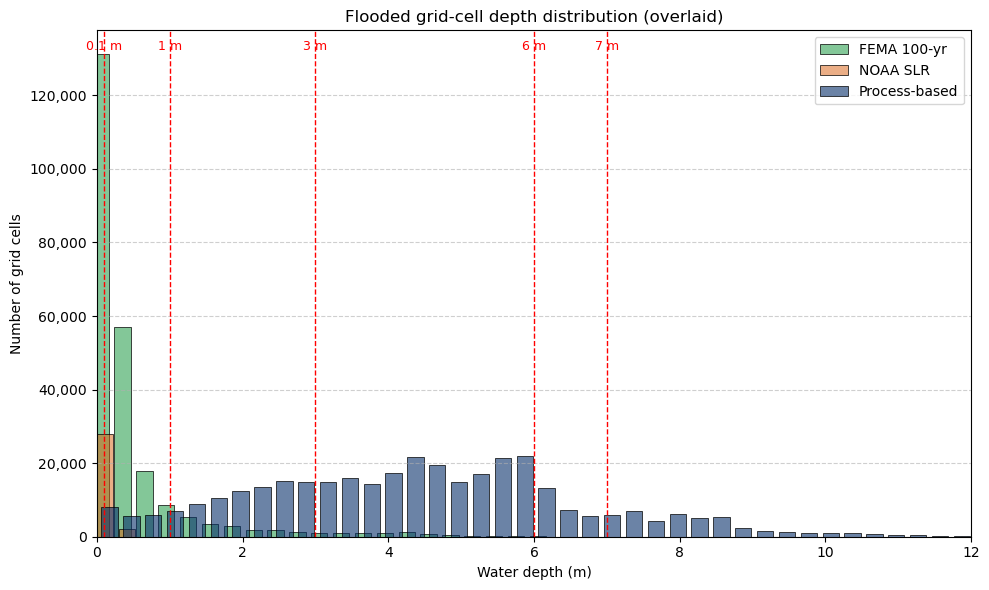

In [5]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# ---------------- USER INPUT ----------------
# Rasters
r_fema     = r"D:\Phd Research\Final_Raster\Fema_100yr_depth_200m.tif"
r_bathtub  = r"C:\Users\sahad2\Research_data\SLR_Depth_Raster_NOAA\SLR_depth_3_5ft_tx_200m_UTM_m.tif"   
r_compound = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"

# Binning and refs
bin_width = 0.3            # meters
x_max = 12.0               # maximum depth to show on x-axis
ref_lines = [0.1, 1.0, 3.0, 6.0, 7.0]

# Plot appearance
colors = {
    "FEMA 100-yr": (49/255, 163/255, 84/255, 0.60),    # green
    "NOAA SLR":     (217/255, 95/255,  14/255, 0.50),   # orange
    "Process-based": (8/255, 48/255, 107/255, 0.60),   # dark blue
}

# Optional: area-normalize bars (km² per bin) instead of cell counts
AREA_NORMALIZE = False
# --------------------------------------------

def depth_values(path, clip_max=None):
    """Read depth raster and return 1D array of valid depths > 0 (optionally ≤ clip_max),
       plus pixel area (m²) if projected in meters, else None."""
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            valid = (arr != nodata) & np.isfinite(arr)
        else:
            valid = np.isfinite(arr)
        vals = arr[valid]
        vals = vals[vals > 0]  # flooded only
        if clip_max is not None:
            vals = vals[vals <= clip_max]

        # pixel area if projected
        pix_area = None
        try:
            if src.crs and not src.crs.is_geographic:
                pix_area = abs(src.transform.a) * abs(src.transform.e)  # m²/pixel
        except Exception:
            pass
    return vals, pix_area

# Common bins across datasets
bins = np.arange(0, x_max + bin_width, bin_width)

series = [
    ("FEMA 100-yr", r_fema),
    ("NOAA SLR", r_bathtub),
    ("Process-based", r_compound),
]

# Compute histograms
hists = []
for name, path in series:
    vals, pix_area = depth_values(path, clip_max=x_max)
    counts, edges = np.histogram(vals, bins=bins)
    if AREA_NORMALIZE:
        if pix_area is None:
            print(f"[WARN] {name}: CRS appears geographic; area normalization skipped for this raster.")
            heights = counts.astype(float)  # fallback to counts
        else:
            heights = counts * (pix_area / 1e6)  # km² per bin
    else:
        heights = counts
    hists.append((name, heights))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Small offsets so bars are visible when overlapping
offsets = {
    "FEMA 100-yr": -0.20 * bin_width,
    "NOAA SLR":      0.00 * bin_width,
    "Process-based": 0.20 * bin_width,
}

for name, heights in hists:
    offset = offsets[name]
    ax.bar(
        bins[:-1] + offset, heights,
        width=bin_width * 0.75,  # slightly narrower than bin to reduce total overlap
        align="edge",
        edgecolor="black",
        linewidth=0.5,
        color=colors[name],
        label=name
    )

# Axis labels, title
ax.set_xlim(0, x_max)
ax.set_xlabel("Water depth (m)")
if AREA_NORMALIZE:
    ax.set_ylabel("Area per depth bin (km²)")
else:
    ax.set_ylabel("Number of grid cells")

ax.set_title("Flooded grid-cell depth distribution (overlaid)")

# Format y axis with thousands separators for readability
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Reference vertical lines
for x in ref_lines:
    if 0 <= x <= x_max:
        ax.axvline(x, linestyle="--", color="red", linewidth=1)
        ax.text(x, ax.get_ylim()[1]*0.98, f"{x:g} m",
                color="red", ha="center", va="top", fontsize=9)

ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend(loc="upper right", frameon=True)
fig.tight_layout()
plt.show()


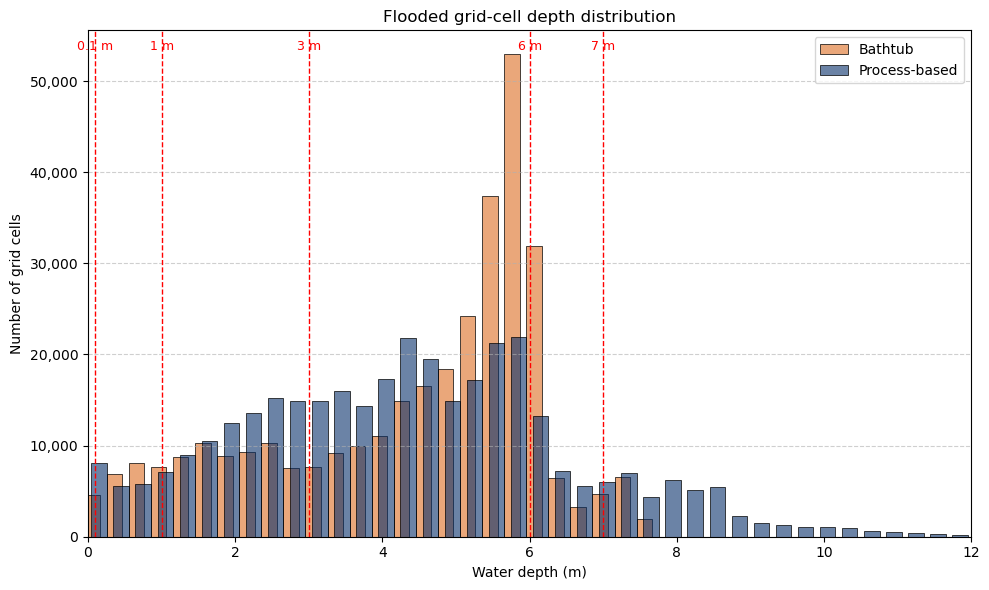

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# ---------------- USER INPUT ----------------
# Rasters
r_bathtub  = r"D:\Phd Research\Final_Raster\Bathtub_depth_100yr_surge_SLR.tif"
r_compound = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"

# Binning and refs
bin_width = 0.3            # meters
x_max = 12.0               # maximum depth to show on x-axis
ref_lines = [0.1, 1.0, 3.0, 6.0, 7.0]

# Plot appearance
colors = {
    "Bathtub":       (217/255, 95/255,  14/255, 0.55),  # orange
    "Process-based": (  8/255, 48/255, 107/255, 0.60),  # dark blue
}

# Optional: area-normalize bars (km² per bin) instead of cell counts
AREA_NORMALIZE = False
# --------------------------------------------

def depth_values(path, clip_max=None):
    """Read depth raster and return 1D array of valid depths > 0 (optionally ≤ clip_max),
       plus pixel area (m²) if projected in meters, else None."""
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata
        valid = np.isfinite(arr) if nodata is None else (arr != nodata) & np.isfinite(arr)
        vals = arr[valid]
        vals = vals[vals > 0]  # flooded only
        if clip_max is not None:
            vals = vals[vals <= clip_max]

        pix_area = None
        try:
            if src.crs and not src.crs.is_geographic:
                pix_area = abs(src.transform.a) * abs(src.transform.e)  # m²/pixel
        except Exception:
            pass
    return vals, pix_area

# Common bins across datasets
bins = np.arange(0, x_max + bin_width, bin_width)

series = [
    ("Bathtub", r_bathtub),
    ("Process-based", r_compound),
]

# Compute histograms
hists = []
for name, path in series:
    vals, pix_area = depth_values(path, clip_max=x_max)
    counts, edges = np.histogram(vals, bins=bins)
    if AREA_NORMALIZE:
        if pix_area is None:
            print(f"[WARN] {name}: CRS appears geographic; area normalization skipped for this raster.")
            heights = counts.astype(float)  # fallback to counts
        else:
            heights = counts * (pix_area / 1e6)  # km² per bin
    else:
        heights = counts
    hists.append((name, heights))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Small offsets so bars are visible when overlapping
offsets = {
    "Bathtub":       -0.15 * bin_width,
    "Process-based":  0.15 * bin_width,
}

for name, heights in hists:
    offset = offsets[name]
    ax.bar(
        bins[:-1] + offset, heights,
        width=bin_width * 0.7,   # slightly narrower to reduce overlap
        align="edge",
        edgecolor="black",
        linewidth=0.5,
        color=colors[name],
        label=name
    )

# Axis labels, title
ax.set_xlim(0, x_max)
ax.set_xlabel("Water depth (m)")
ax.set_ylabel("Area per depth bin (km²)" if AREA_NORMALIZE else "Number of grid cells")
ax.set_title("Flooded grid-cell depth distribution")

# Format y axis with thousands separators for readability
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Reference vertical lines
for x in ref_lines:
    if 0 <= x <= x_max:
        ax.axvline(x, linestyle="--", color="red", linewidth=1)
        ymax = ax.get_ylim()[1]
        ax.text(x, ymax*0.98, f"{x:g} m", color="red", ha="center", va="top", fontsize=9)

ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend(loc="upper right", frameon=True)
fig.tight_layout()
plt.show()


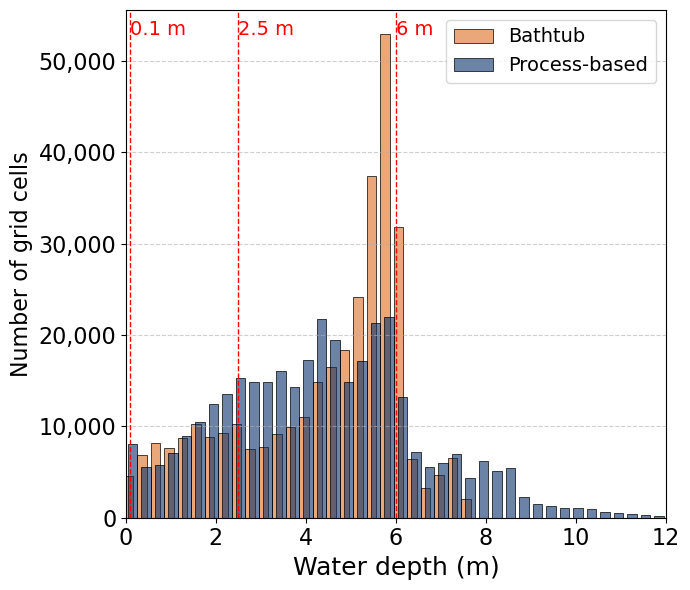

In [5]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# ---------------- USER INPUT ----------------
# Rasters
r_bathtub  = r"D:\Phd Research\Final_Raster\Bathtub_depth_100yr_surge_SLR.tif"
r_compound = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"

# Binning and refs
bin_width = 0.3            # meters
x_max = 12.0               # maximum depth to show on x-axis
ref_lines = [0.1, 2.5, 6.0]

# Plot appearance
colors = {
    "Bathtub":       (217/255, 95/255,  14/255, 0.55),  # orange
    "Process-based": (  8/255, 48/255, 107/255, 0.60),  # dark blue
}

# Optional: area-normalize bars (km² per bin) instead of cell counts
AREA_NORMALIZE = False
# --------------------------------------------

def depth_values(path, clip_max=None):
    """Read depth raster and return 1D array of valid depths > 0 (optionally ≤ clip_max),
       plus pixel area (m²) if projected in meters, else None."""
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata
        valid = np.isfinite(arr) if nodata is None else (arr != nodata) & np.isfinite(arr)
        vals = arr[valid]
        vals = vals[vals > 0]  # flooded only
        if clip_max is not None:
            vals = vals[vals <= clip_max]

        pix_area = None
        try:
            if src.crs and not src.crs.is_geographic:
                pix_area = abs(src.transform.a) * abs(src.transform.e)  # m²/pixel
        except Exception:
            pass
    return vals, pix_area

# Common bins across datasets
bins = np.arange(0, x_max + bin_width, bin_width)

series = [
    ("Bathtub", r_bathtub),
    ("Process-based", r_compound),
]

# Compute histograms
hists = []
for name, path in series:
    vals, pix_area = depth_values(path, clip_max=x_max)
    counts, edges = np.histogram(vals, bins=bins)
    if AREA_NORMALIZE:
        if pix_area is None:
            print(f"[WARN] {name}: CRS appears geographic; area normalization skipped for this raster.")
            heights = counts.astype(float)  # fallback to counts
        else:
            heights = counts * (pix_area / 1e6)  # km² per bin
    else:
        heights = counts
    hists.append((name, heights))

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

# Small offsets so bars are visible when overlapping
offsets = {
    "Bathtub":       -0.15 * bin_width,
    "Process-based":  0.15 * bin_width,
}

for name, heights in hists:
    offset = offsets[name]
    ax.bar(
        bins[:-1] + offset, heights,
        width=bin_width * 0.7,   # slightly narrower to reduce overlap
        align="edge",
        edgecolor="black",
        linewidth=0.5,
        color=colors[name],
        label=name
    )

# Axis labels, title
ax.set_xlim(0, x_max)
ax.set_xlabel("Water depth (m)", fontsize = 18)
ax.set_ylabel("Area per depth bin (km²)" if AREA_NORMALIZE else "Number of grid cells", fontsize = 16)
# ax.set_title("Flooded grid-cell depth distribution")

# Format y axis with thousands separators for readability
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Increase tick font sizes (NEW)
ax.tick_params(axis='both', labelsize=16)

# Reference vertical lines
for x in ref_lines:
    if 0 <= x <= x_max:
        ax.axvline(x, linestyle="--", color="red", linewidth=1)
        ymax = ax.get_ylim()[1]
        ax.text(x, ymax*0.98, f"{x:g} m", color="red", ha="left", va="top", fontsize=14)

ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend(loc="upper right", frameon=True, fontsize = 14)
fig.tight_layout()
plt.show()


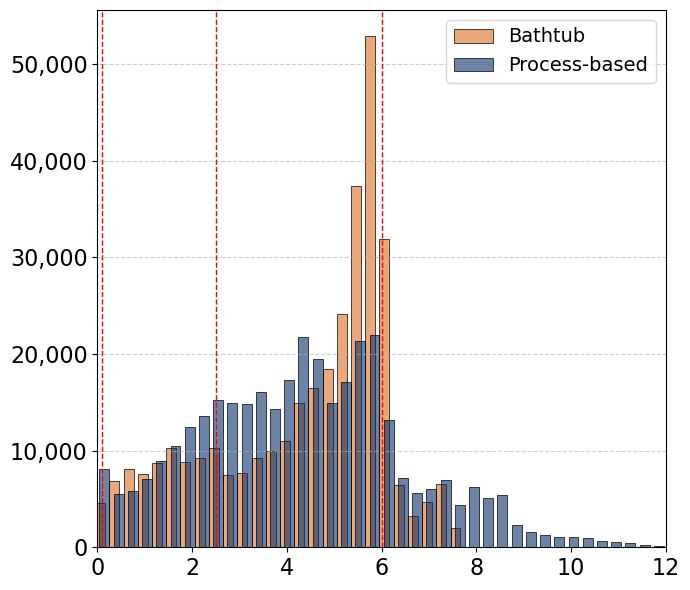

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# ---------------- USER INPUT ----------------
# Rasters
r_bathtub  = r"D:\Phd Research\Final_Raster\Bathtub_depth_100yr_surge_SLR.tif"
r_compound = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"

# Binning and refs
bin_width = 0.3            # meters
x_max = 12.0               # maximum depth to show on x-axis
ref_lines = [0.1, 2.5, 6.0]

# Plot appearance
colors = {
    "Bathtub":       (217/255, 95/255,  14/255, 0.55),  # orange
    "Process-based": (  8/255, 48/255, 107/255, 0.60),  # dark blue
}

# Optional: area-normalize bars (km² per bin) instead of cell counts
AREA_NORMALIZE = False
# --------------------------------------------

def depth_values(path, clip_max=None):
    """Read depth raster and return 1D array of valid depths > 0 (optionally ≤ clip_max),
       plus pixel area (m²) if projected in meters, else None."""
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata
        valid = np.isfinite(arr) if nodata is None else (arr != nodata) & np.isfinite(arr)
        vals = arr[valid]
        vals = vals[vals > 0]  # flooded only
        if clip_max is not None:
            vals = vals[vals <= clip_max]

        pix_area = None
        try:
            if src.crs and not src.crs.is_geographic:
                pix_area = abs(src.transform.a) * abs(src.transform.e)  # m²/pixel
        except Exception:
            pass
    return vals, pix_area

# Common bins across datasets
bins = np.arange(0, x_max + bin_width, bin_width)

series = [
    ("Bathtub", r_bathtub),
    ("Process-based", r_compound),
]

# Compute histograms
hists = []
for name, path in series:
    vals, pix_area = depth_values(path, clip_max=x_max)
    counts, edges = np.histogram(vals, bins=bins)
    if AREA_NORMALIZE:
        if pix_area is None:
            print(f"[WARN] {name}: CRS appears geographic; area normalization skipped for this raster.")
            heights = counts.astype(float)  # fallback to counts
        else:
            heights = counts * (pix_area / 1e6)  # km² per bin
    else:
        heights = counts
    hists.append((name, heights))

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

# Small offsets so bars are visible when overlapping
offsets = {
    "Bathtub":       -0.15 * bin_width,
    "Process-based":  0.15 * bin_width,
}

for name, heights in hists:
    offset = offsets[name]
    ax.bar(
        bins[:-1] + offset, heights,
        width=bin_width * 0.7,   # slightly narrower to reduce overlap
        align="edge",
        edgecolor="black",
        linewidth=0.5,
        color=colors[name],
        label=name
    )

# Axis labels, title
ax.set_xlim(0, x_max)
# ax.set_xlabel("Water depth (m)", fontsize = 18)
# ax.set_ylabel("Area per depth bin (km²)" if AREA_NORMALIZE else "Number of grid cells", fontsize = 16)
# ax.set_title("Flooded grid-cell depth distribution")

# Format y axis with thousands separators for readability
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Increase tick font sizes (NEW)
ax.tick_params(axis='both', labelsize=16)

# Reference vertical lines
for x in ref_lines:
    if 0 <= x <= x_max:
        ax.axvline(x, linestyle="--", color="red", linewidth=1)
        ymax = ax.get_ylim()[1]
        # ax.text(x, ymax*0.98, f"{x:g} m", color="red", ha="left", va="top", fontsize=14)

ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend(loc="upper right", frameon=True, fontsize = 14)
fig.tight_layout()
plt.show()
